In [7]:
from preprocessing.load_dataset import SubCorBatDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]



# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels


# Training configuration
batch_files = sorted(metadata["batch_file"].unique())

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column


METADATA: Original rows: 23652
METADATA: Remaining rows: 23652


In [9]:
batch_files[0]

'/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_OASIS3/batch_0001.npz'

In [16]:
dataset = SubCorBatDataset(metadata, batch_files[7], labels_bb_df, n_structs=-1)

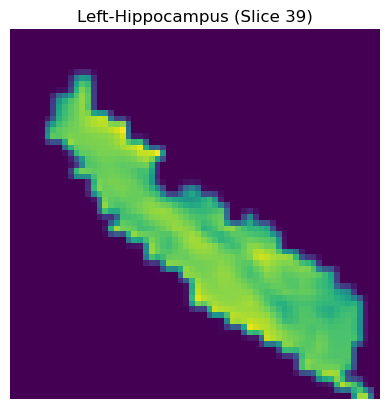

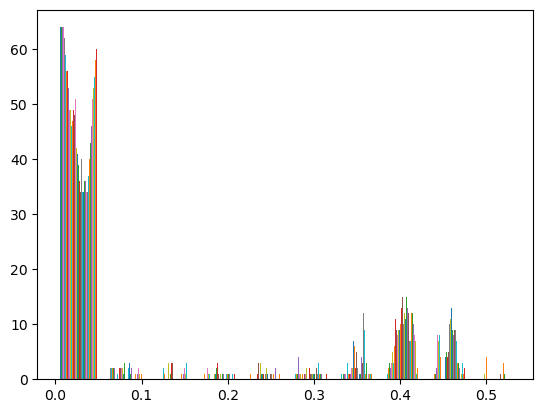

In [15]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_sub = 2
i_str = 12

sample = dataset[i_sub]
struct = sample["image"][i_str, 0]  # [D, H, W]

# Find the z-slice (axial) where the structure has the highest total intensity
z_profile = struct.sum(axis=(1, 2))  # Sum over H and W → shape: [D]
z_max = torch.argmax(z_profile).item()

# Plot that slice
plt.imshow(struct[z_max].cpu())
plt.title(f"{sample['struct_name'][i_str]} (Slice {z_max})")
plt.axis('off')
plt.show()
metadata.query(f"GUID == '{sample['GUID'][i_str]}'")[["subject"]].values[0,0]

plt.hist(struct[z_max].cpu())
plt.show()


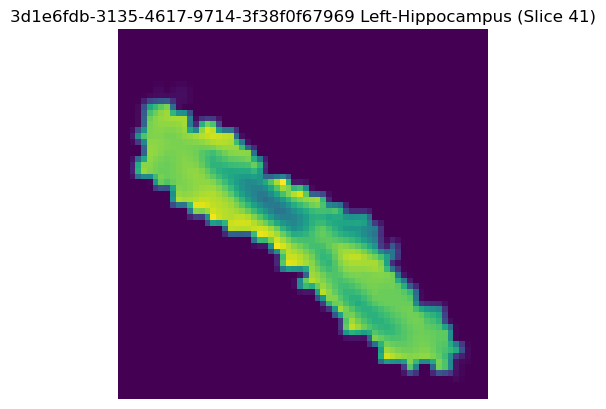

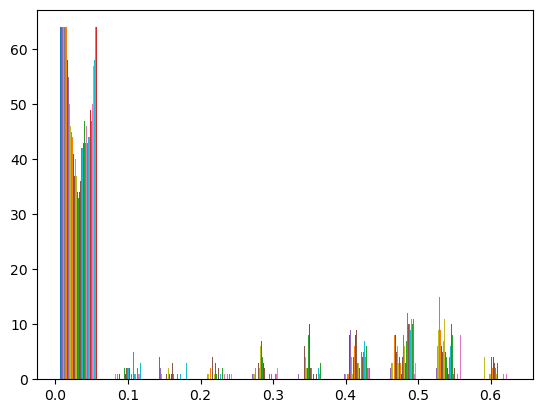

In [17]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_sub = 556
i_str = 12

sample = dataset[i_sub]
struct = sample["image"][i_str, 0]  # [D, H, W]

# Find the z-slice (axial) where the structure has the highest total intensity
z_profile = struct.sum(axis=(1, 2))  # Sum over H and W → shape: [D]
z_max = torch.argmax(z_profile).item()

# Plot that slice
plt.imshow(struct[z_max].cpu())
plt.title(f"{sample['GUID'][i_str]} {sample['struct_name'][i_str]} (Slice {z_max})")
plt.axis('off')
plt.show()

metadata.query(f"GUID == '{sample['GUID'][i_str]}'")[["subject"]].values[0,0]

plt.hist(struct[z_max].cpu())
plt.show()


In [8]:
import numpy as np

npz_data = np.load("/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/region_brain/batched_adni/batch_0001.npz")
mus = np.array(npz_data["mus"])
guids = np.array(npz_data["GUID"])
label_name = np.array(npz_data["LabelName"])


In [2]:
!ls /mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/region_brain/batched_adni


batch_0001.npz	batch_0006.npz	batch_0011.npz	batch_0016.npz	batch_0021.npz
batch_0002.npz	batch_0007.npz	batch_0012.npz	batch_0017.npz	batch_0022.npz
batch_0003.npz	batch_0008.npz	batch_0013.npz	batch_0018.npz
batch_0004.npz	batch_0009.npz	batch_0014.npz	batch_0019.npz
batch_0005.npz	batch_0010.npz	batch_0015.npz	batch_0020.npz


In [6]:
mus.shape

(988, 113, 8, 8, 8, 8)

In [10]:
label_name.shape

(1, 113)

In [11]:
1000*22

22000

In [16]:
dataset.images

array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
    